# FlowSense exploratory data analysis

This notebook examines the cleaned traffic sensor data before any adaptive controller, model, simulation, dashboard, or prediction system is built. The cleaned CSV is read-only input; no source data is modified.

In [18]:
from pathlib import Path

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid", context="notebook")
pd.set_option("display.max_columns", None)

data_path = Path("../data/processed/traffic_cleaned.csv")
df = pd.read_csv(data_path)
df["timestamp_utc"] = pd.to_datetime(df["timestamp_utc"], utc=True)
df.head()

,timestamp_utc,intersection_id,intersection_name,lat,lon,approach,lane_count,vehicle_count_15min,avg_speed_kmh,queue_length_m,signal_phase_sec_green,signal_phase_sec_red,is_rush_hour,weather,notes
0,2026-09-13 00:00:00+00:00,INT-EXPO-E,Expo district east approach,48.174,11.5542,E,1,34,33,4,25,63,0,light_rain,synthetic anonymized counts for Adaptive Traff...
1,2026-09-13 00:15:00+00:00,INT-EXPO-E,Expo district east approach,48.174,11.5542,E,1,42,36,17,26,67,0,light_rain,synthetic anonymized counts for Adaptive Traff...
2,2026-09-13 00:30:00+00:00,INT-EXPO-E,Expo district east approach,48.174,11.5542,E,1,31,36,2,26,61,0,light_rain,synthetic anonymized counts for Adaptive Traff...
3,2026-09-13 00:45:00+00:00,INT-EXPO-E,Expo district east approach,48.174,11.5542,E,1,44,37,26,25,69,0,light_rain,synthetic anonymized counts for Adaptive Traff...
4,2026-09-13 01:00:00+00:00,INT-EXPO-E,Expo district east approach,48.174,11.5542,E,1,36,27,15,23,67,0,light_rain,synthetic anonymized counts for Adaptive Traff...


## 1. Load and verify the cleaned dataset

In [19]:
verification = {
    "shape": df.shape,
    "timestamp_range": (df["timestamp_utc"].min(), df["timestamp_utc"].max()),
    "intersections": df["intersection_id"].nunique(),
    "approaches": df["approach"].nunique(),
    "timestamps": df["timestamp_utc"].nunique(),
    "null_values": int(df.isna().sum().sum()),
    "duplicate_rows": int(df.duplicated().sum()),
}
for name, value in verification.items():
    print(f"{name}: {value}")

print("\nColumn names:")
print(df.columns.tolist())

print("\nData types:")
display(df.dtypes.to_frame("dtype"))

assert verification["null_values"] == 0
assert verification["duplicate_rows"] == 0

shape: (16128, 15)
timestamp_range: (Timestamp('2026-09-13 00:00:00+0000', tz='UTC'), Timestamp('2026-09-19 23:45:00+0000', tz='UTC'))
intersections: 6
approaches: 4
timestamps: 672
null_values: 0
duplicate_rows: 0

Column names:
['timestamp_utc', 'intersection_id', 'intersection_name', 'lat', 'lon', 'approach', 'lane_count', 'vehicle_count_15min', 'avg_speed_kmh', 'queue_length_m', 'signal_phase_sec_green', 'signal_phase_sec_red', 'is_rush_hour', 'weather', 'notes']

Data types:


,dtype
timestamp_utc,"datetime64[ns, UTC]"
intersection_id,object
intersection_name,object
lat,float64
lon,float64
approach,object
lane_count,int64
vehicle_count_15min,int64
avg_speed_kmh,int64
queue_length_m,int64


## 2. Traffic demand over time

Each row is one intersection/approach observation for a 15-minute timestamp. Summing `vehicle_count_15min` across rows gives the observed network demand at each timestamp.

Average network demand is highest around 09:00 and lowest around 02:00 UTC.


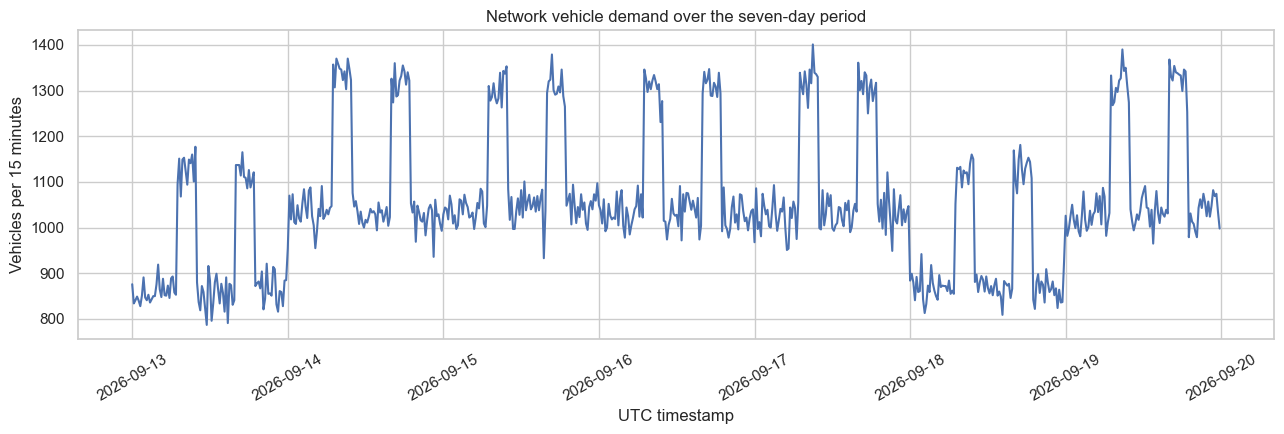

In [20]:
demand_by_timestamp = (
    df.groupby("timestamp_utc", as_index=False)["vehicle_count_15min"]
    .sum()
    .rename(columns={"vehicle_count_15min": "total_vehicle_count_15min"})
)

fig, ax = plt.subplots(figsize=(13, 4.5))
sns.lineplot(data=demand_by_timestamp, x="timestamp_utc", y="total_vehicle_count_15min", ax=ax)
ax.set(title="Network vehicle demand over the seven-day period", xlabel="UTC timestamp", ylabel="Vehicles per 15 minutes")
plt.xticks(rotation=30)
plt.tight_layout()

daily_hourly_demand = (
    df.assign(hour=df["timestamp_utc"].dt.hour)
    .groupby([df["timestamp_utc"].dt.day_name(), "hour"], sort=False)["vehicle_count_15min"]
    .sum()
    .reset_index(name="total_vehicle_count_15min")
)

hourly_network_demand = (
    df.assign(hour=df["timestamp_utc"].dt.hour)
    .groupby("hour")["vehicle_count_15min"]
    .sum()
    .div(df["timestamp_utc"].dt.normalize().nunique())
)
peak_hour = int(hourly_network_demand.idxmax())
low_hour = int(hourly_network_demand.idxmin())
print(f"Average network demand is highest around {peak_hour:02d}:00 and lowest around {low_hour:02d}:00 UTC.")

## 3. Hourly traffic patterns

Hourly averages retain the scale of an individual sensor row, which makes vehicle count, queue length, and speed comparable across hours.

,average_vehicle_count_15min,average_queue_length_m,average_speed_kmh
hour,,,
0,40.78,15.62,37.55
1,40.93,16.11,37.97
2,40.71,15.99,37.84
3,41.20,15.89,37.60
4,40.72,15.75,37.61
5,40.99,15.92,37.71
6,41.19,16.30,37.73
7,52.45,62.61,19.66
8,52.62,62.61,19.40


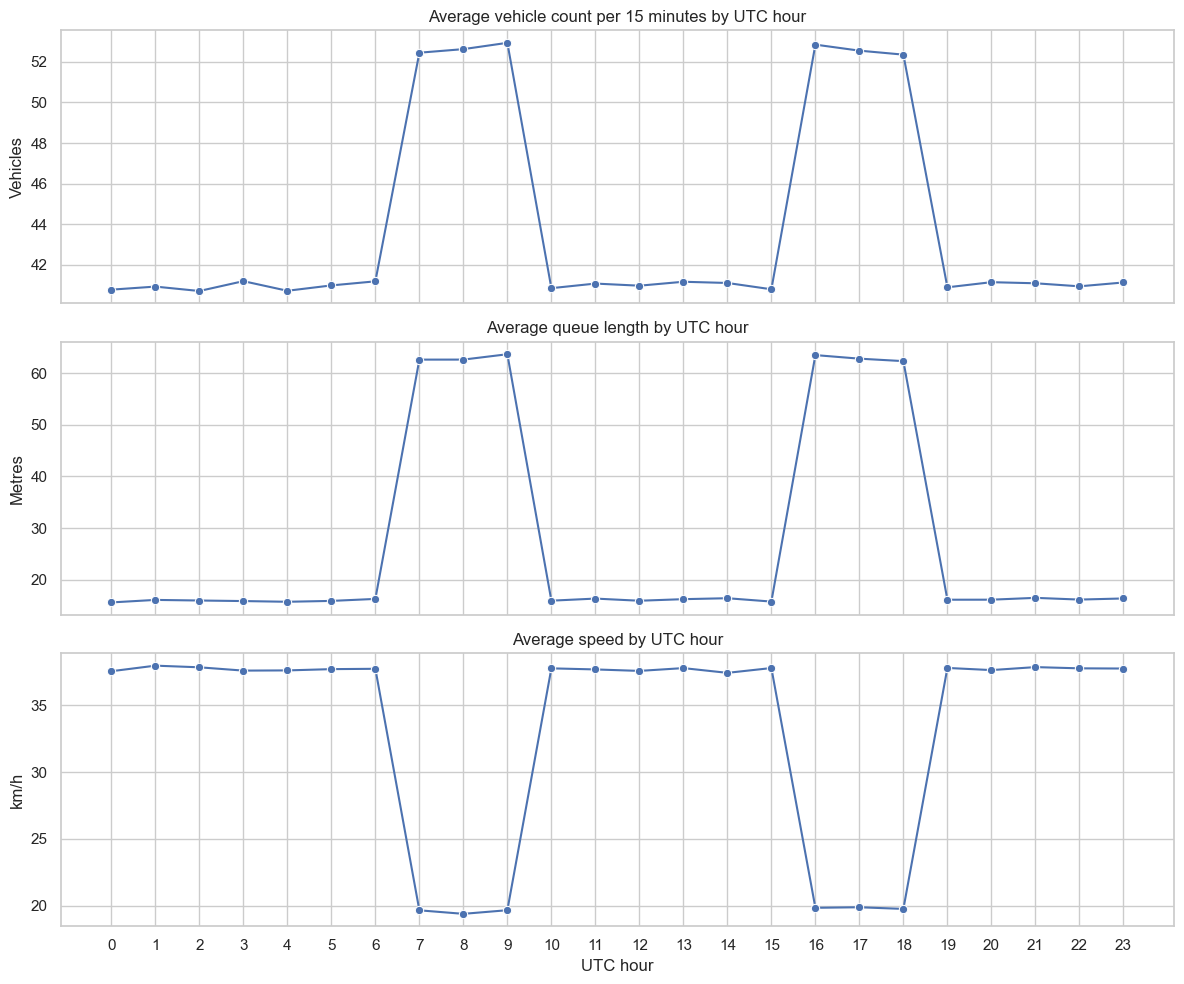

In [22]:
df["hour"] = df["timestamp_utc"].dt.hour
hourly_summary = (
    df.groupby("hour")[["vehicle_count_15min", "queue_length_m", "avg_speed_kmh"]]
    .mean()
    .rename(columns={
        "vehicle_count_15min": "average_vehicle_count_15min",
        "queue_length_m": "average_queue_length_m",
        "avg_speed_kmh": "average_speed_kmh",
    })
)
display(hourly_summary.round(2))

fig, axes = plt.subplots(3, 1, figsize=(12, 10), sharex=True)
series = [
    ("average_vehicle_count_15min", "Average vehicle count per 15 minutes", "Vehicles"),
    ("average_queue_length_m", "Average queue length", "Metres"),
    ("average_speed_kmh", "Average speed", "km/h"),
]
for ax, (column, title, ylabel) in zip(axes, series):
    sns.lineplot(x=hourly_summary.index, y=hourly_summary[column], marker="o", ax=ax)
    ax.set(title=title + " by UTC hour", xlabel="UTC hour" if ax is axes[-1] else "", ylabel=ylabel)
    ax.set_xticks(range(24))
plt.tight_layout()

## 4. Rush hour versus non-rush hour

,vehicle_count_15min,queue_length_m,avg_speed_kmh
rush_period,,,
Non-rush hour,40.98,16.09,37.71
Rush hour,52.63,62.91,19.70


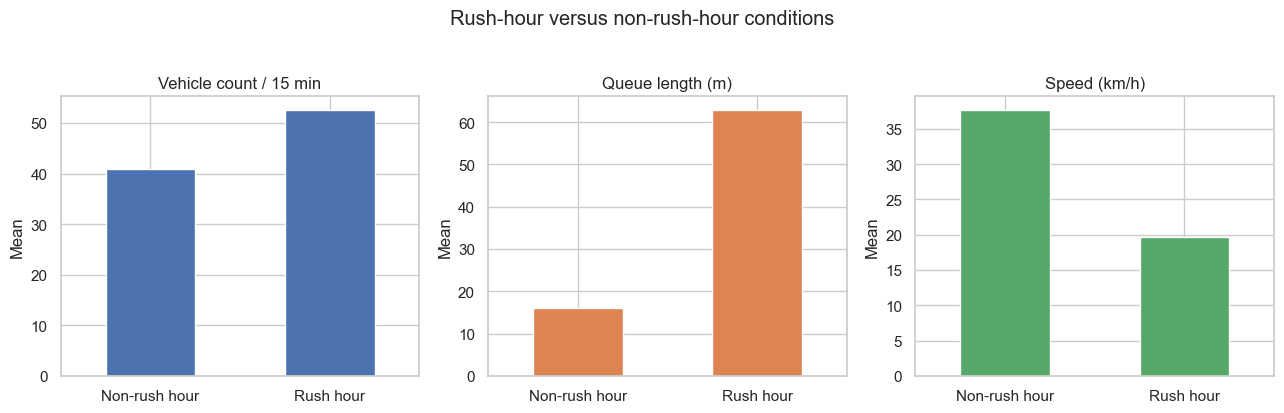

In [21]:
rush_summary = (
    df.assign(rush_period=df["is_rush_hour"].map({0: "Non-rush hour", 1: "Rush hour", False: "Non-rush hour", True: "Rush hour"}))
    .groupby("rush_period")[["vehicle_count_15min", "queue_length_m", "avg_speed_kmh"]]
    .mean()
    .reindex(["Non-rush hour", "Rush hour"])
)
display(rush_summary.round(2))

rush_plot = rush_summary.rename(columns={
    "vehicle_count_15min": "Vehicle count / 15 min",
    "queue_length_m": "Queue length (m)",
    "avg_speed_kmh": "Speed (km/h)",
})
ax = rush_plot.plot(kind="bar", subplots=True, layout=(1, 3), figsize=(13, 4), legend=False, rot=0)
for axis, title in zip(np.ravel(ax), rush_plot.columns):
    axis.set_title(title)
    axis.set_xlabel("")
    axis.set_ylabel("Mean")
plt.suptitle("Rush-hour versus non-rush-hour conditions", y=1.03)
plt.tight_layout()

## 5. Intersection and approach differences

Intersection averages:


,,vehicle_count_15min,queue_length_m,avg_speed_kmh
intersection_id,intersection_name,,,
INT-EXPO-E,Expo district east approach,43.98,27.96,33.20
INT-EXPO-N,Expo district north approach,43.90,27.81,33.30
INT-EXPO-S,Expo district south approach,43.85,27.85,33.23
INT-EXPO-W,Expo district west approach,43.95,27.86,33.18
INT-RING-01,Inner ring connector A,43.90,27.82,33.20
INT-RING-02,Inner ring connector B,43.80,27.48,33.15


Approach averages:


,vehicle_count_15min,queue_length_m,avg_speed_kmh
approach,,,
N,43.81,27.58,33.27
E,43.81,27.85,33.19
S,43.87,27.74,33.17
W,44.08,28.02,33.21



Intersections ranked by longer queues and lower speeds:


,,queue_length_m,avg_speed_kmh,vehicle_count_15min
intersection_id,intersection_name,,,
INT-EXPO-E,Expo district east approach,27.96,33.20,43.98
INT-EXPO-W,Expo district west approach,27.86,33.18,43.95
INT-EXPO-S,Expo district south approach,27.85,33.23,43.85
INT-RING-01,Inner ring connector A,27.82,33.20,43.90
INT-EXPO-N,Expo district north approach,27.81,33.30,43.90
INT-RING-02,Inner ring connector B,27.48,33.15,43.80


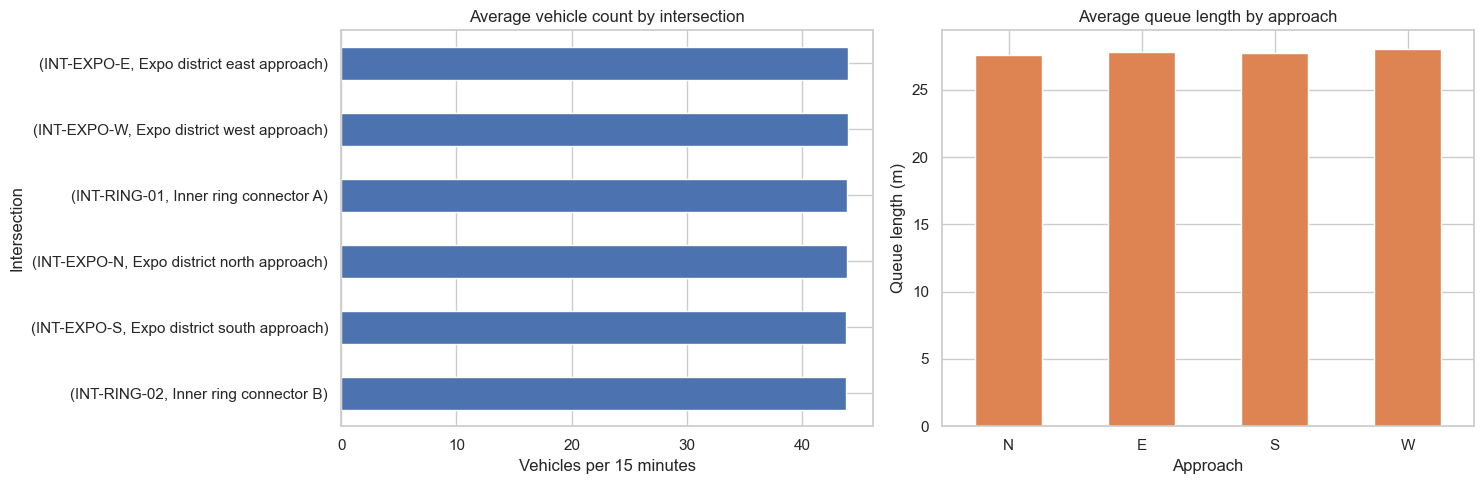

In [23]:
metrics = ["vehicle_count_15min", "queue_length_m", "avg_speed_kmh"]
intersection_summary = df.groupby(["intersection_id", "intersection_name"])[metrics].mean().round(2)
approach_summary = df.groupby("approach")[metrics].mean().reindex(["N", "E", "S", "W"]).round(2)

print("Intersection averages:")
display(intersection_summary)
print("Approach averages:")
display(approach_summary)

fig, axes = plt.subplots(1, 2, figsize=(15, 5))
intersection_summary["vehicle_count_15min"].sort_values().plot(kind="barh", ax=axes[0], color="C0")
axes[0].set(title="Average vehicle count by intersection", xlabel="Vehicles per 15 minutes", ylabel="Intersection")
approach_summary["queue_length_m"].plot(kind="bar", ax=axes[1], color="C1", rot=0)
axes[1].set(title="Average queue length by approach", xlabel="Approach", ylabel="Queue length (m)")
plt.tight_layout()

congestion_by_intersection = intersection_summary.sort_values(["queue_length_m", "avg_speed_kmh"], ascending=[False, True])
print("\nIntersections ranked by longer queues and lower speeds:")
display(congestion_by_intersection[["queue_length_m", "avg_speed_kmh", "vehicle_count_15min"]])

## 6. Relationships between traffic variables

Pearson correlations summarize linear association in this sample; scatter plots show the underlying spread rather than treating correlation as causation.

,vehicle_count_15min,queue_length_m,avg_speed_kmh
vehicle_count_15min,1.000,0.835,-0.342
queue_length_m,0.835,1.000,-0.622
avg_speed_kmh,-0.342,-0.622,1.000


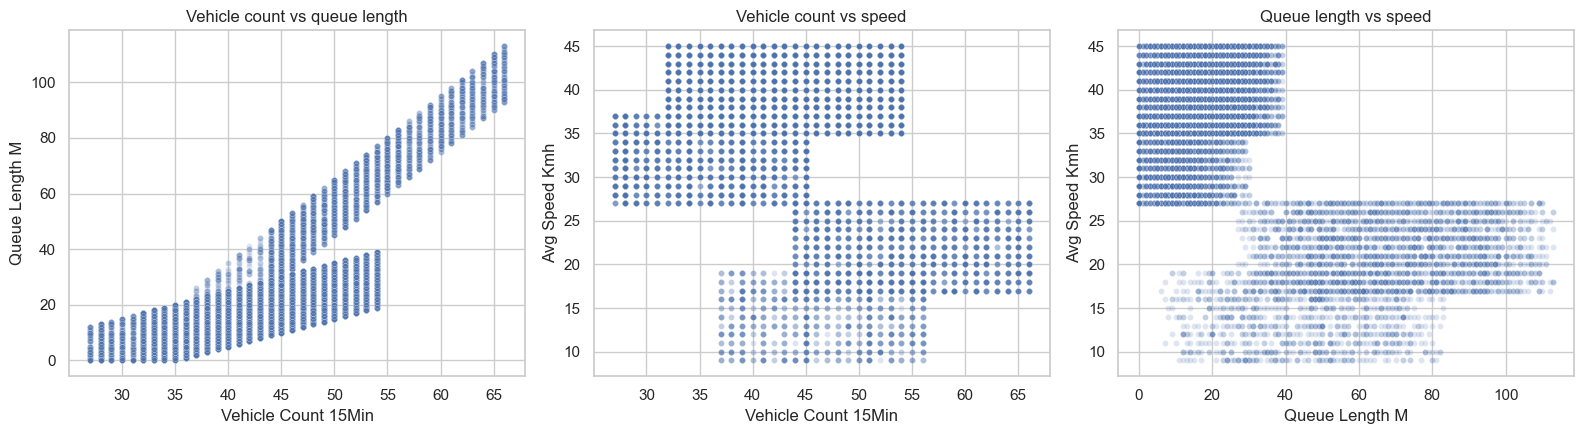

In [24]:
relationship_columns = ["vehicle_count_15min", "queue_length_m", "avg_speed_kmh"]
correlations = df[relationship_columns].corr()
display(correlations.round(3))

fig, axes = plt.subplots(1, 3, figsize=(16, 4.5))
pairs = [
    ("vehicle_count_15min", "queue_length_m", "Vehicle count vs queue length"),
    ("vehicle_count_15min", "avg_speed_kmh", "Vehicle count vs speed"),
    ("queue_length_m", "avg_speed_kmh", "Queue length vs speed"),
]
for ax, (x, y, title) in zip(axes, pairs):
    sns.scatterplot(data=df, x=x, y=y, alpha=0.18, s=18, ax=ax)
    ax.set(title=title, xlabel=x.replace("_", " ").title(), ylabel=y.replace("_", " ").title())
plt.tight_layout()

## 7. Fixed baseline signal timing

These green and red durations are the existing fixed baseline. They are analyzed as observations to compare against later; they are not an adaptive controller.

,count,mean,std,min,25%,50%,75%,max
signal_phase_sec_green,16128.0,27.28,4.16,22.0,24.0,27.0,29.0,40.0
signal_phase_sec_red,16128.0,62.72,5.23,45.0,60.0,63.0,66.0,73.0


Unique green durations: [22, 23, 24, 25, 26, 27, 28, 29, 30, 32, 33, 34, 35, 36, 37, 38, 39, 40]
Unique red durations: [45, 46, 47, 48, 49, 50, 51, 52, 53, 54, 55, 56, 57, 58, 59, 60, 61, 62, 63, 64, 65, 66, 67, 68, 69, 70, 71, 72, 73]


,vehicle_count_15min,signal_phase_sec_green,signal_phase_sec_red
hour,,,
0,40.78,26.03,63.97
1,40.93,26.22,63.92
2,40.71,26.01,63.80
3,41.20,26.19,63.82
4,40.72,25.71,64.18
5,40.99,26.21,63.85
6,41.19,26.09,63.92
7,52.45,31.04,58.94
8,52.62,30.99,58.99


Correlation of vehicle count with green duration: 0.294
Correlation of vehicle count with red duration: -0.229


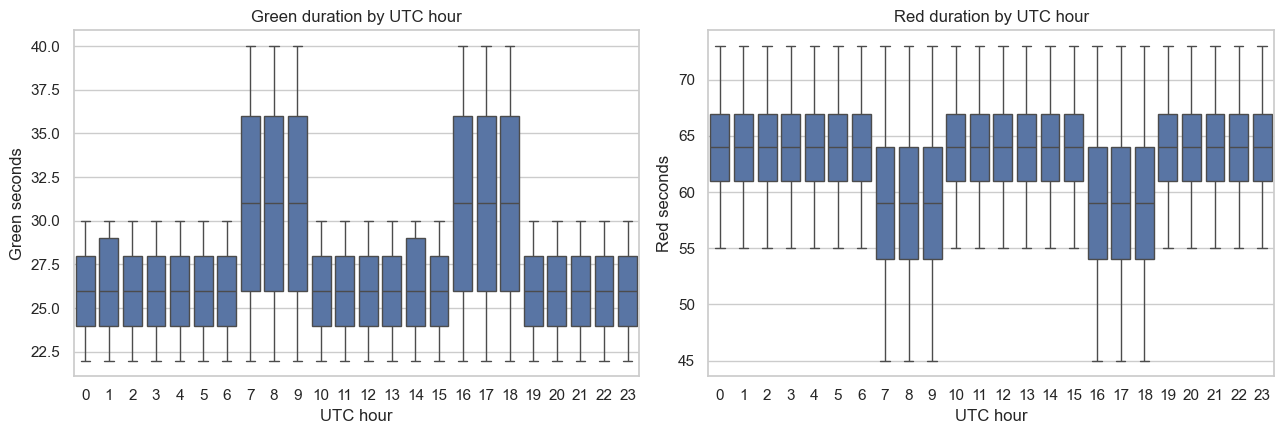

In [25]:
timing_columns = ["signal_phase_sec_green", "signal_phase_sec_red"]
timing_summary = df[timing_columns].describe().T.round(2)
display(timing_summary)
print("Unique green durations:", sorted(df["signal_phase_sec_green"].unique()))
print("Unique red durations:", sorted(df["signal_phase_sec_red"].unique()))

timing_by_demand = df.groupby("hour")[["vehicle_count_15min"] + timing_columns].mean()
display(timing_by_demand.round(2))

fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))
sns.boxplot(data=df, x="hour", y="signal_phase_sec_green", ax=axes[0])
axes[0].set(title="Green duration by UTC hour", xlabel="UTC hour", ylabel="Green seconds")
sns.boxplot(data=df, x="hour", y="signal_phase_sec_red", ax=axes[1])
axes[1].set(title="Red duration by UTC hour", xlabel="UTC hour", ylabel="Red seconds")
plt.tight_layout()

green_demand_corr = df[["vehicle_count_15min", "signal_phase_sec_green"]].corr().iloc[0, 1]
red_demand_corr = df[["vehicle_count_15min", "signal_phase_sec_red"]].corr().iloc[0, 1]
print(f"Correlation of vehicle count with green duration: {green_demand_corr:.3f}")
print(f"Correlation of vehicle count with red duration: {red_demand_corr:.3f}")

## 8. Weather differences

Weather categories: ['clear', 'cloudy', 'light_rain']


,vehicle_count_15min,queue_length_m,avg_speed_kmh
weather,,,
clear,46.00,30.99,35.46
cloudy,45.86,30.86,35.59
light_rain,38.70,19.87,27.52


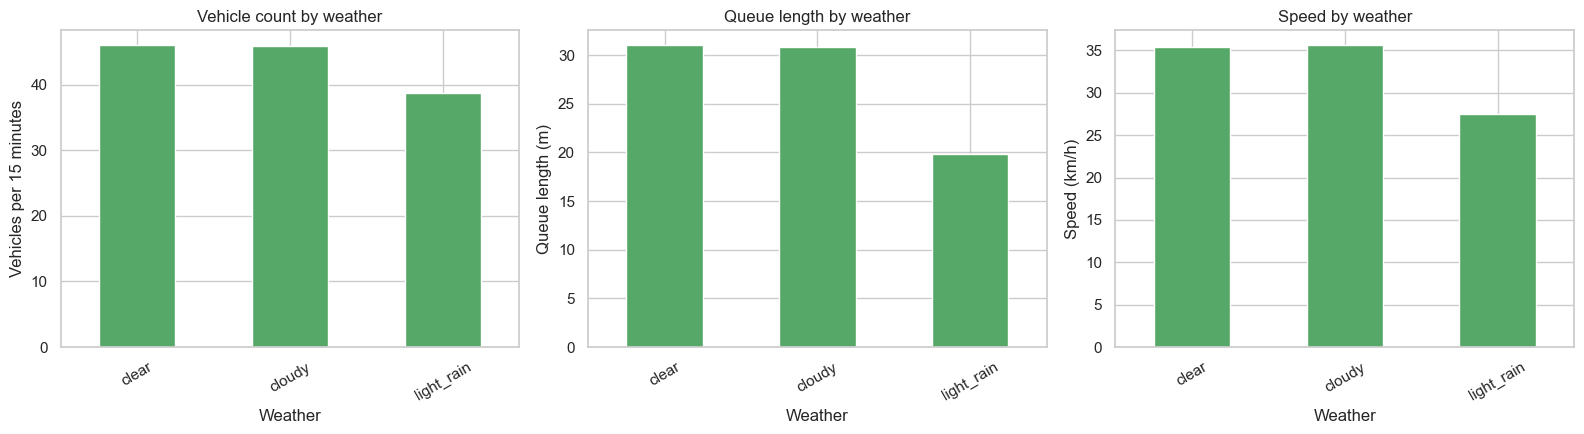

In [26]:
print("Weather categories:", sorted(df["weather"].unique()))
weather_summary = df.groupby("weather")[metrics].mean().sort_values("queue_length_m", ascending=False).round(2)
display(weather_summary)

fig, axes = plt.subplots(1, 3, figsize=(16, 4.5))
for ax, column, title, ylabel in zip(
    axes,
    metrics,
    ["Vehicle count by weather", "Queue length by weather", "Speed by weather"],
    ["Vehicles per 15 minutes", "Queue length (m)", "Speed (km/h)"],
):
    weather_summary[column].plot(kind="bar", ax=ax, rot=30, color="C2")
    ax.set(title=title, xlabel="Weather", ylabel=ylabel)
plt.tight_layout()


## 9. Congestion patterns

In [27]:
peak_demand_row = demand_by_timestamp.loc[demand_by_timestamp["total_vehicle_count_15min"].idxmax()]
longest_queue_row = df.loc[df["queue_length_m"].idxmax()]
lowest_speed_row = df.loc[df["avg_speed_kmh"].idxmin()]
highest_demand_intersection = intersection_summary["vehicle_count_15min"].idxmax()
highest_queue_intersection = intersection_summary["queue_length_m"].idxmax()
highest_queue_approach = approach_summary["queue_length_m"].idxmax()

print(f"Highest network demand: {peak_demand_row['total_vehicle_count_15min']:.0f} vehicles at {peak_demand_row['timestamp_utc']} UTC.")
print(f"Longest observed queue: {longest_queue_row['queue_length_m']:.0f} m at {longest_queue_row['timestamp_utc']} UTC, {longest_queue_row['intersection_id']} approach {longest_queue_row['approach']}.")
print(f"Lowest observed speed: {lowest_speed_row['avg_speed_kmh']:.0f} km/h at {lowest_speed_row['timestamp_utc']} UTC, {lowest_speed_row['intersection_id']} approach {lowest_speed_row['approach']}.")
print(f"Highest-demand intersection by average: {highest_demand_intersection}.")
print(f"Longest-queue intersection by average: {highest_queue_intersection}.")
print(f"Longest-queue approach by average: {highest_queue_approach}.")
print(f"Vehicle count / queue correlation: {correlations.loc['vehicle_count_15min', 'queue_length_m']:.3f}.")
print(f"Vehicle count / speed correlation: {correlations.loc['vehicle_count_15min', 'avg_speed_kmh']:.3f}.")
print(f"Queue / speed correlation: {correlations.loc['queue_length_m', 'avg_speed_kmh']:.3f}.")

Highest network demand: 1401 vehicles at 2026-09-17 09:00:00+00:00 UTC.
Longest observed queue: 113 m at 2026-09-16 07:15:00+00:00 UTC, INT-EXPO-N approach E.
Lowest observed speed: 9 km/h at 2026-09-13 17:45:00+00:00 UTC, INT-EXPO-E approach E.
Highest-demand intersection by average: ('INT-EXPO-E', 'Expo district east approach').
Longest-queue intersection by average: ('INT-EXPO-E', 'Expo district east approach').
Longest-queue approach by average: W.
Vehicle count / queue correlation: 0.835.
Vehicle count / speed correlation: -0.342.
Queue / speed correlation: -0.622.


## EDA Findings for Adaptive Signal Control

The statements below are generated from the summary tables above rather than assumed in advance. The highest and lowest values identify where traffic pressure is concentrated; the correlations describe association in this dataset and do not by themselves establish causation.


In [28]:
rush_delta = rush_summary.loc["Rush hour"] - rush_summary.loc["Non-rush hour"]
demand_change = "higher" if rush_delta["vehicle_count_15min"] > 0 else "lower"
queue_change = "longer" if rush_delta["queue_length_m"] > 0 else "shorter"
speed_change = "higher" if rush_delta["avg_speed_kmh"] > 0 else "lower"
green_variability = df["signal_phase_sec_green"].nunique()
red_variability = df["signal_phase_sec_red"].nunique()

print("Actual findings")
print(f"- Rush-hour observations have {demand_change} vehicle counts, {queue_change} queues, and {speed_change} speeds than non-rush observations.")
print(f"- Average demand is highest at about {peak_hour:02d}:00 UTC and lowest at about {low_hour:02d}:00 UTC, showing a recurring hourly pattern in the seven-day sample.")
print(f"- {highest_demand_intersection} has the highest average intersection demand, while {highest_queue_intersection} has the highest average queue length.")
print(f"- Approach {highest_queue_approach} has the highest average queue length; approach averages should therefore not be assumed to be balanced.")
print(f"- Vehicle count, queue length, and speed should be considered together: the observed correlations are {correlations.loc['vehicle_count_15min', 'queue_length_m']:.2f} (count/queue), {correlations.loc['vehicle_count_15min', 'avg_speed_kmh']:.2f} (count/speed), and {correlations.loc['queue_length_m', 'avg_speed_kmh']:.2f} (queue/speed).")
print(f"- Fixed timing has {green_variability} distinct green durations and {red_variability} distinct red durations. Its relationship with demand should be checked against the timing tables before treating it as responsive.")
print("\nImplications for the next stage")
print("- Candidate traffic-pressure inputs are vehicle count, queue length, and speed, with intersection and approach identity retained so directional differences are visible.")
print("- The controller should respond to recurring high-demand hours and localized long-queue/low-speed conditions rather than using a single network-wide average alone.")
print("- Later evaluation should compare any adaptive strategy with this fixed green/red baseline using demand, queue length, speed, and fairness across approaches; no improvement is claimed by this EDA.")

Actual findings
- Rush-hour observations have higher vehicle counts, longer queues, and lower speeds than non-rush observations.
- Average demand is highest at about 09:00 UTC and lowest at about 02:00 UTC, showing a recurring hourly pattern in the seven-day sample.
- ('INT-EXPO-E', 'Expo district east approach') has the highest average intersection demand, while ('INT-EXPO-E', 'Expo district east approach') has the highest average queue length.
- Approach W has the highest average queue length; approach averages should therefore not be assumed to be balanced.
- Vehicle count, queue length, and speed should be considered together: the observed correlations are 0.83 (count/queue), -0.34 (count/speed), and -0.62 (queue/speed).
- Fixed timing has 18 distinct green durations and 29 distinct red durations. Its relationship with demand should be checked against the timing tables before treating it as responsive.

Implications for the next stage
- Candidate traffic-pressure inputs are vehicle